<h4 align="center"><i>In the name of Allah, the Most Gracious, the Most Merciful</i></h4>

# 🎓 Project Title: **Gas_Price_Analysis**

**with two files**

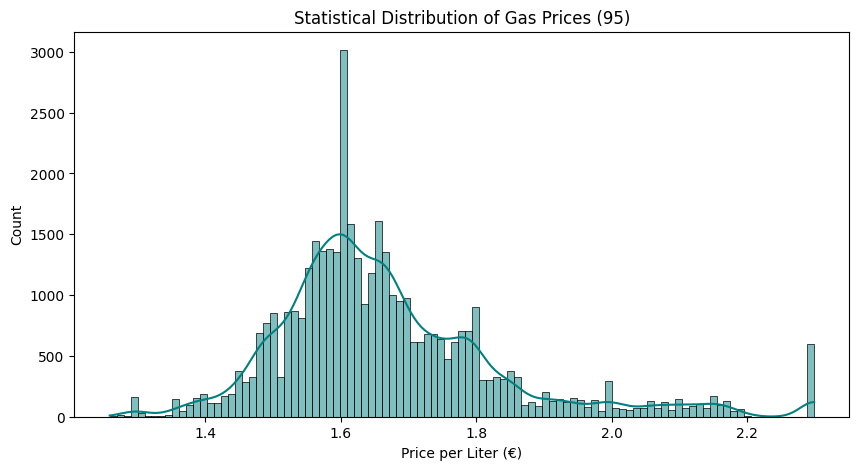

C:\Users\hp\AppData\Local\Temp\ipykernel_12600\2593557540.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['rotulo'].isin(top_10_brands)], x='rotulo', y='precio_gasolina_95', palette='viridis')


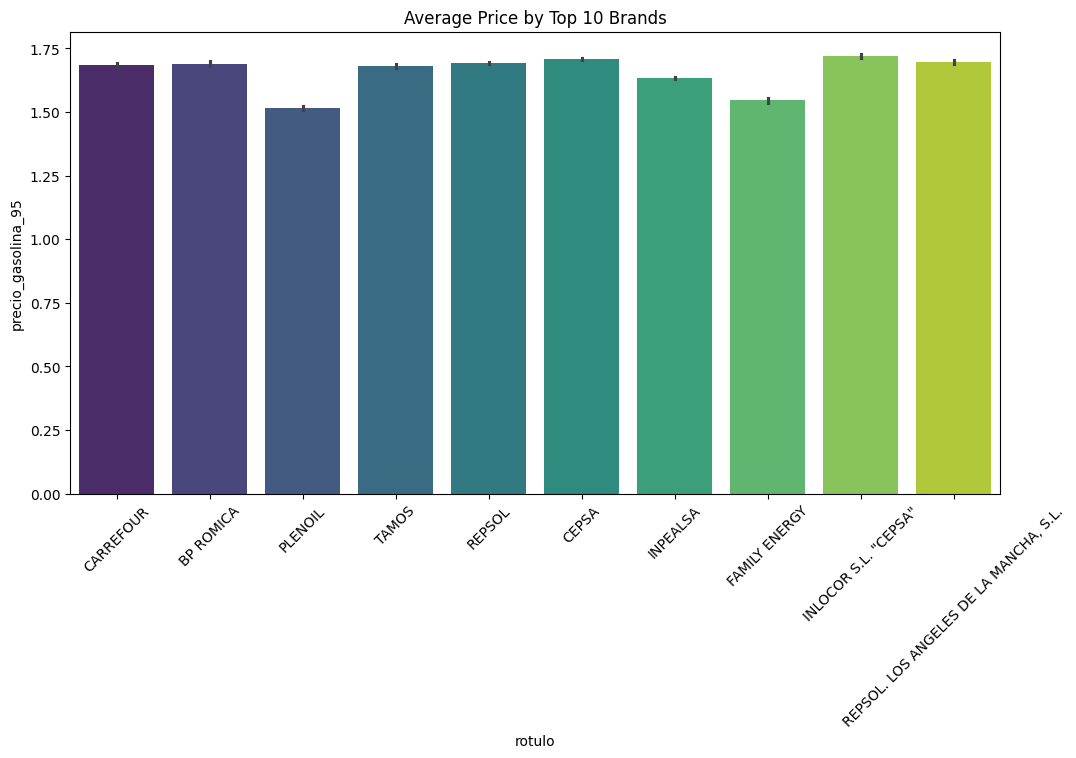

C:\Users\hp\AppData\Local\Temp\ipykernel_12600\2593557540.py:49: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(df, lat="latitud", lon="longitud", color="precio_gasolina_95",


2026/04/29 06:31:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/29 06:31:35 INFO mlflow.store.db.utils: Updating database tables
2026-04-29 06:31:35 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-04-29 06:31:35 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-04-29 06:31:35 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-04-29 06:31:35 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026/04/29 06:31:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 06:31:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/29 06:31:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Success! Model R2: 0.3411
✅ Success! Model R2: 0.3411 and saved in production_models/


In [1]:
# --- 1. SETTING THE STAGE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import mlflow
import mlflow.sklearn
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# FIX: Initialize MLflow with a local SQLite database to avoid folder errors
db_path = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(db_path)

# --- 2. DATA INGESTION & INTEGRATION ---
# Merging spatial data with price data (Lecture 2/3 Concept)
stations = pd.read_csv('data/gasolineras_ab.csv')
prices = pd.read_csv('data/precios_gasolineras.csv')
df = pd.merge(prices, stations, on='id_estacion')

# Cleaning: Drop missing prices for our target (Gasoline 95)
df = df.dropna(subset=['precio_gasolina_95'])

# --- 3. MULTI-FORM DATA VISUALIZATION (EDA) ---

# A. Statistical View: Distribution of Prices
plt.figure(figsize=(10, 5))
sns.histplot(df['precio_gasolina_95'], kde=True, color='teal')
plt.title('Statistical Distribution of Gas Prices (95)')
plt.xlabel('Price per Liter (€)')
plt.show()

# B. Brand Comparison: Which companies are more expensive?
plt.figure(figsize=(12, 6))
top_10_brands = df['rotulo'].value_counts().nlargest(10).index
sns.barplot(data=df[df['rotulo'].isin(top_10_brands)], x='rotulo', y='precio_gasolina_95', palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Price by Top 10 Brands')
plt.show()

# C. Geographical View: Interactive Map (Lecture 5 Style)
fig = px.scatter_mapbox(df, lat="latitud", lon="longitud", color="precio_gasolina_95",
                        size="precio_gasolina_95", hover_name="rotulo",
                        color_continuous_scale=px.colors.cyclical.IceFire, 
                        zoom=10, mapbox_style="open-street-map",
                        title="Interactive Map: Fuel Prices in Albacete")
fig.show()

df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')
df['month'] = df['fecha'].dt.month

# --- 4. PRODUCTION PIPELINE & MLFLOW ---
X = df[['latitud', 'longitud', 'rotulo', 'month']]
y = df['precio_gasolina_95']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline (Categorical + Numerical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['latitud', 'longitud','month']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['rotulo'])
    ])

mlflow.set_experiment("Gas_Price_Advanced_Analysis")

with mlflow.start_run(run_name="RandomForest_Final"):
    # Build Model Pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=150, random_state=42))
    ])
    
    # Train
    model.fit(X_train, y_train)
    
    # Evaluate
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    # Log to MLflow
    mlflow.log_metric("R2_Score", r2)
    mlflow.log_metric("RMSE", rmse)
    mlflow.sklearn.log_model(model, "gas_model")
    
    
    
    output_dir = 'production_models'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Directory '{output_dir}' created successfully!")
        
    
    
    # Save model file for Streamlit
joblib.dump(model, os.path.join(output_dir, 'gas_price_model.pkl'))
print(f"✅ Success! Model R2: {r2:.4f}")
print(f"✅ Success! Model R2: {r2:.4f} and saved in {output_dir}/")

In [ ]:
# --- 1. SETTING THE STAGE ---
import pandas as pd
import numpy as np
import os
import mlflow
import mlflow.sklearn
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Initialize MLflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# --- 2. DATA INGESTION & INTEGRATION ---
stations = pd.read_csv("data/gasolineras_ab.csv")
prices = pd.read_csv("data/precios_gasolineras.csv")

df = pd.merge(prices, stations, on="id_estacion")

df = df.dropna(subset=["precio_gasolina_95"])
df = df[df["precio_gasolina_95"] > 0.5] 

z_scores = np.abs(stats.zscore(df["precio_gasolina_95"]))
df = df[z_scores < 3]

# --- 3. FEATURE ENGINEERING ---
df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")
df["day_of_year"] = df["fecha"].dt.dayofyear
df["day_of_week"] = df["fecha"].dt.dayofweek

# --- 4. PRODUCTION PIPELINE ---
X = df[["latitud", "longitud", "rotulo", "day_of_year", "day_of_week"]]
y = df["precio_gasolina_95"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# البايبلاين مع TargetEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            ["latitud", "longitud", "day_of_year", "day_of_week"],
        ),
        ("cat", TargetEncoder(target_type="continuous"), ["rotulo"]),
    ]
)

mlflow.set_experiment("Gas_Price_Professional_Optimization")

with mlflow.start_run(run_name="Final_Optimized_Model"):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                GradientBoostingRegressor(
                    n_estimators=1000,
                    learning_rate=0.01,
                    max_depth=8,
                    subsample=0.8,
                    random_state=42,
                ),
            ),
        ]
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # تسجيل النتائج
    mlflow.log_metric("R2_Score", r2)
    mlflow.log_metric("RMSE", rmse)

    # حفظ الموديل
    output_dir = "production_models"
    os.makedirs(output_dir, exist_ok=True)
    joblib.dump(model, os.path.join(output_dir, "gas_price_model.pkl"))

print(f" Improved R2 Score: {r2:.4f}")

2026/04/29 06:44:45 INFO mlflow.tracking.fluent: Experiment with name 'Gas_Price_Professional_Optimization' does not exist. Creating a new experiment.


🔥 Success! Improved R2 Score: 0.6576
